In [1]:
import pandas as pd
import import_ipynb
import nbimporter

from utils import prepareTrainingSet3Sec,standardization,metrics,Grafico_Before_After_Standardization,Grafico_Before_After_GridSearch,Grafico_Tre_Valori,evaluate_Model# type: ignore

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt  
from sklearn.metrics import accuracy_score



BASE 

Eseguo il randomForest senza standardizazione

In [2]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
model=RandomForestClassifier(n_estimators=300, max_depth=6) 
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)
before_standardization= accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)



---------STATISTICHE TEST----------
Accuratezza: 0.6747
Precision: 0.6677
Recall: 0.6750
F1-score: 0.6586
F2-score: 0.6661
---------STATISTICHE TRAING----------
Accuratezza: 0.7250
Precision: 0.7262
Recall: 0.7248
F1-score: 0.7167
F2-score: 0.7199

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


Applichiamo la standardizzazione

In [10]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test= standardization(X_train, X_test)

model=RandomForestClassifier(n_estimators=300, max_depth=6) 
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
after_standardization= accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)

evaluate_Model(y_test, y_pred,y_train, y_pred_train)


---------STATISTICHE TEST----------
Accuratezza: 0.6722
Precision: 0.6653
Recall: 0.6725
F1-score: 0.6578
F2-score: 0.6645
---------STATISTICHE TRAING----------
Accuratezza: 0.7225
Precision: 0.7257
Recall: 0.7224
F1-score: 0.7154
F2-score: 0.7179

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


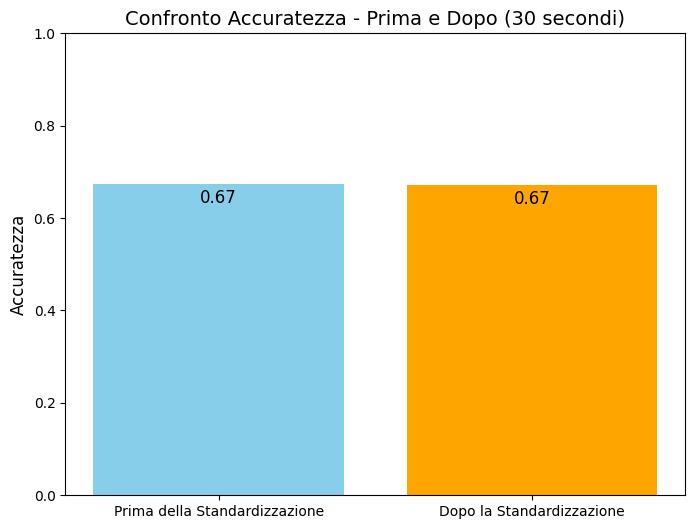

In [4]:
Grafico_Before_After_Standardization(before_standardization, after_standardization)

Uso il gridSearch per ottimizzare i iperparametri e avere delle soluzione migliori

In [9]:
# Supponiamo che prepareTrainingSet3Sec, encode_labels e standardization siano definite altrove
X_train, X_test, y_train, y_test = prepareTrainingSet3Sec()
X_train, X_test = standardization(X_train, X_test)

# Definisci il modello
model = RandomForestClassifier()

# Definisci la griglia dei parametri per GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Esegui GridSearchCV
grid_search = GridSearchCV(model, param_grid, cv=5, n_jobs=-1, verbose=2)
grid_search.fit(X_train, y_train)

# Filtra i modelli con differenza di accuracy entro il 10%
valid_models = []
for params in grid_search.cv_results_['params']:
    model.set_params(**params)
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    if abs(train_accuracy - test_accuracy) <= 0.10 and train_accuracy < 0.99:
        valid_models.append((model, params, train_accuracy, test_accuracy))

# Trova il miglior modello tra quelli validi
if valid_models:
    best_model, best_params, best_train_accuracy, best_test_accuracy = max(valid_models, key=lambda x: x[3])
    print(f"Training Accuracy: {best_train_accuracy}")
    print(f"Testing Accuracy: {best_test_accuracy}")
    print(f"Best Parameters: {best_params}")
    print("La differenza tra l'accuracy di training e di test è entro il 10%.")
else:
    print("Nessun modello ha una differenza di accuracy entro il 10%.")

Fitting 5 folds for each of 48 candidates, totalling 240 fits


KeyboardInterrupt: 

In [ ]:
Grafico_Tre_Valori(before_standardization,after_standardization,after_Grid)

NameError: name 'before_3sec_standadization' is not defined